### SENTINEL — Custom CNN Lane Detection

**Notebook 03** — Multi-task CNN trained **from scratch** (no pretrained weights).  
Predicts `has_lane` (binary) and `left_poly` + `right_poly` (6 coefficients) jointly.

Consumes `processed/labels_{train,val,test}.json` produced by Notebook 01.

**Architecture (CIE-552 requirement: custom, not a standard named arch):**
```
Input 3×180×320
  └─ Conv(32,3×3) → BN → ReLU → MaxPool(2×2)   → 32×90×160
  └─ Conv(64,3×3) → BN → ReLU → MaxPool(2×2)   → 64×45×80
  └─ Conv(128,3×3)→ BN → ReLU → MaxPool(2×2)   → 128×22×40
  └─ Flatten → FC(512) → ReLU → Dropout(0.5)
       ├─ Head A: FC(1) + sigmoid  → has_lane
       └─ Head B: FC(6)            → [left_a,b,c | right_a,b,c]
```
Loss: `BCE(has_lane) + λ * MSE(polynomials)`,  λ = 1.0

---
## Cell 1 — Imports and config

In [1]:
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

# ── Constants (must match notebooks 01 and 02) ─────────────────────
IMG_W, IMG_H  = 320, 180
LOOKAHEAD_PX  = 45
SEED          = 42
PROCESSED_DIR = Path("processed")

# ── Training hyperparameters ─────────────────────────────────
BATCH_SIZE   = 32
LR           = 1e-3
EPOCHS       = 50
PATIENCE     = 10         # early-stopping patience (val loss)
LAMBDA_POLY  = 1.0        # weight of polynomial MSE in total loss
WEIGHT_DECAY = 1e-4

# ── Paths ───────────────────────────────────────────────
MODEL_PATH      = PROCESSED_DIR / "custom_cnn.pth"
NORM_STATS_PATH = PROCESSED_DIR / "poly_norm_stats.npz"

# ── Device ─────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device:      {DEVICE}")
print(f"Resolution:  {IMG_W}x{IMG_H}")
print(f"Batch size:  {BATCH_SIZE}  |  LR: {LR}  |  Epochs: {EPOCHS}  |  Patience: {PATIENCE}")
print(f"Lambda poly: {LAMBDA_POLY}  |  Weight decay: {WEIGHT_DECAY}")

Device:      cuda
Resolution:  320x180
Batch size:  32  |  LR: 0.001  |  Epochs: 50  |  Patience: 10
Lambda poly: 1.0  |  Weight decay: 0.0001


---
## Cell 2 — Load labels and compute polynomial normalisation stats

The regression target is a 6-vector `[left_a, left_b, left_c, right_a, right_b, right_c]`.
Raw polynomial coefficients have very different scales (`a` ≈ 10⁻³, `c` ≈ 0–320), so we
z-score normalise using per-coefficient mean and std computed on the training set.
The normalisation parameters are saved to `processed/poly_norm_stats.npz` so that
Notebooks 04–06 can reuse them without re-computing.

In [2]:
with open(PROCESSED_DIR / "labels_train.json", "r", encoding="utf-8") as f:
    train_labels = json.load(f)
with open(PROCESSED_DIR / "labels_val.json", "r", encoding="utf-8") as f:
    val_labels = json.load(f)
with open(PROCESSED_DIR / "labels_test.json", "r", encoding="utf-8") as f:
    test_labels = json.load(f)

print(f"Train: {len(train_labels)}  |  Val: {len(val_labels)}  |  Test: {len(test_labels)}")

# Collect all [left_a, left_b, left_c, right_a, right_b, right_c] from training set
poly_vecs = [
    lbl["left_poly"] + lbl["right_poly"]
    for lbl in train_labels
    if lbl["has_lane"]
]
poly_vecs = np.array(poly_vecs, dtype=np.float32)

POLY_MEAN = poly_vecs.mean(axis=0)
POLY_STD  = poly_vecs.std(axis=0) + 1e-8   # guard against zero-variance

np.savez(str(NORM_STATS_PATH), mean=POLY_MEAN, std=POLY_STD)

coeff_names = ["left_a", "left_b", "left_c", "right_a", "right_b", "right_c"]
print(f"\nPoly normalisation stats (from {len(poly_vecs)} training samples):")
print(f"  {'Coeff':<10}  {'Mean':>12}  {'Std':>12}")
for name, m, s in zip(coeff_names, POLY_MEAN, POLY_STD):
    print(f"  {name:<10}  {m:12.6f}  {s:12.6f}")
print(f"\nSaved normalisation stats to: {NORM_STATS_PATH}")

Train: 2538  |  Val: 543  |  Test: 545

Poly normalisation stats (from 2538 training samples):
  Coeff               Mean           Std
  left_a         -0.000198      0.007395
  left_b         -1.155551      1.571537
  left_c        230.113647     84.208046
  right_a         0.000589      0.014500
  right_b         1.424764      2.770885
  right_c        75.286133    137.289307

Saved normalisation stats to: processed/poly_norm_stats.npz


---
## Cell 3 — LaneDataset and DataLoaders

The dataset loads a 320×180 PNG, converts BGR→RGB, normalises pixels to [0, 1],
and returns a CHW float tensor. The polynomial target is z-score normalised using
the training-set statistics computed in Cell 2.

> **Note on class balance:** TuSimple is a curated dataset — every image has
> `has_lane = True`. The BCE head will learn to always predict 1, which is correct
> for this distribution. The polynomial MSE head carries the main learning signal.
> In deployment, `has_lane = False` is emitted by the FSM when the lane disappears
> mid-run, not by this model.

In [3]:
class LaneDataset(Dataset):
    """Wraps processed/images + label JSON for lane detection training."""

    def __init__(self, labels, poly_mean, poly_std):
        self.labels    = labels
        self.poly_mean = poly_mean   # np.ndarray shape (6,)
        self.poly_std  = poly_std

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        lbl = self.labels[idx]

        img = cv2.imread(lbl["image"])
        if img is None:
            img = np.zeros((IMG_H, IMG_W, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        img_t = torch.from_numpy(img.transpose(2, 0, 1))  # CHW

        has_lane_t = torch.tensor([1.0 if lbl["has_lane"] else 0.0])

        if lbl["has_lane"]:
            raw = np.array(lbl["left_poly"] + lbl["right_poly"], dtype=np.float32)
            poly_t = torch.from_numpy((raw - self.poly_mean) / self.poly_std)
        else:
            poly_t = torch.zeros(6, dtype=torch.float32)

        return img_t, has_lane_t, poly_t


train_ds = LaneDataset(train_labels, POLY_MEAN, POLY_STD)
val_ds   = LaneDataset(val_labels,   POLY_MEAN, POLY_STD)
test_ds  = LaneDataset(test_labels,  POLY_MEAN, POLY_STD)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Sanity check: one batch shape
imgs, cls_t, poly_t = next(iter(train_loader))
print(f"\nBatch shapes — img: {tuple(imgs.shape)}, cls: {tuple(cls_t.shape)}, poly: {tuple(poly_t.shape)}")

Train batches: 80
Val batches:   17
Test batches:  18

Batch shapes — img: (32, 3, 180, 320), cls: (32, 1), poly: (32, 6)


---
## Cell 4 — SentinelLaneCNN architecture

A custom three-block convolutional backbone followed by a shared fully-connected
neck and two task-specific heads. Architecture is designed from scratch — it does
not replicate any standard named model (VGG, ResNet, MobileNet, etc.).

| Stage | Output shape | Receptive field grows |
|---|---|---|
| Input | 3 × 180 × 320 | — |
| Block 1 (Conv32 + Pool) | 32 × 90 × 160 | 3×3 → effective 3 |
| Block 2 (Conv64 + Pool) | 64 × 45 × 80 | effective 7 |
| Block 3 (Conv128 + Pool)| 128 × 22 × 40 | effective 15 |
| Flatten + FC(512) + Drop | 512 | — |
| Head A: FC(1) + sigmoid | scalar | has_lane ∈ [0,1] |
| Head B: FC(6) | 6 floats | normalised poly coefficients |

In [4]:
class SentinelLaneCNN(nn.Module):
    """
    Custom multi-task CNN for lane detection.

    Spatial flow: 3x180x320 -> 32x90x160 -> 64x45x80 -> 128x22x40
    flat_size = 128 * 22 * 40 = 112 640
    """

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3,   32,  kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 2
            nn.Conv2d(32,  64,  kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 3
            nn.Conv2d(64,  128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # 128 * floor(180/8) * floor(320/8) = 128 * 22 * 40 = 112 640
        flat_size = 128 * 22 * 40

        self.neck = nn.Sequential(
            nn.Linear(flat_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
        )

        self.head_cls  = nn.Linear(512, 1)   # has_lane (sigmoid applied in forward)
        self.head_poly = nn.Linear(512, 6)   # [left_a,b,c | right_a,b,c], normalised

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.neck(x)
        return torch.sigmoid(self.head_cls(x)), self.head_poly(x)


model = SentinelLaneCNN().to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"SentinelLaneCNN — trainable parameters: {n_params:,}")

# Shape sanity check
with torch.no_grad():
    dummy = torch.zeros(2, 3, IMG_H, IMG_W, device=DEVICE)
    cls_out, poly_out = model(dummy)
print(f"Output shapes — cls: {tuple(cls_out.shape)}, poly: {tuple(poly_out.shape)}")

SentinelLaneCNN — trainable parameters: 57,769,479
Output shapes — cls: (2, 1), poly: (2, 6)


---
## Cell 5 — Loss function and epoch runner

**Multi-task loss:**
```
L = BCE(pred_cls, true_cls) + λ * MSE(pred_poly, true_poly)
```
The polynomial MSE is computed **only on samples where `has_lane = True`**
to avoid penalising the regression head on invalid targets.

In [5]:
def multitask_loss(pred_cls, pred_poly, true_cls, true_poly):
    """Returns (total, bce_scalar, mse_scalar)."""
    bce = F.binary_cross_entropy(pred_cls, true_cls)

    lane_mask = true_cls.squeeze(1).bool()
    if lane_mask.sum() > 0:
        mse = F.mse_loss(pred_poly[lane_mask], true_poly[lane_mask])
    else:
        mse = torch.tensor(0.0, device=pred_cls.device)

    total = bce + LAMBDA_POLY * mse
    return total, bce.item(), mse.item()


def run_epoch(loader, model, optimizer=None):
    """One training or validation pass. Returns (avg_total, avg_bce, avg_mse)."""
    training = optimizer is not None
    model.train() if training else model.eval()

    total_sum = bce_sum = mse_sum = 0.0
    n_batches = 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, cls_t, poly_t in loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            cls_t  = cls_t.to(DEVICE, non_blocking=True)
            poly_t = poly_t.to(DEVICE, non_blocking=True)

            pred_cls, pred_poly = model(imgs)
            loss, bce_v, mse_v = multitask_loss(pred_cls, pred_poly, cls_t, poly_t)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_sum += loss.item()
            bce_sum   += bce_v
            mse_sum   += mse_v
            n_batches += 1

    n = max(n_batches, 1)
    return total_sum / n, bce_sum / n, mse_sum / n


print("Loss function and epoch runner defined.")

Loss function and epoch runner defined.


---
## Cell 6 — Training loop

- **Optimiser:** Adam with weight decay 1e-4
- **LR schedule:** ReduceLROnPlateau (factor=0.5, patience=5) — halves LR when val loss stalls
- **Early stopping:** stop if val loss does not improve for `PATIENCE=10` epochs
- **Checkpoint:** best model weights saved to `processed/custom_cnn.pth`

In [6]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6
)

history = {
    "train_loss": [], "val_loss": [],
    "train_bce":  [], "val_bce":  [],
    "train_mse":  [], "val_mse":  [],
}

best_val_loss    = float("inf")
patience_counter = 0
best_epoch       = 0

print(f"Training SentinelLaneCNN for up to {EPOCHS} epochs (early-stop patience={PATIENCE})")
print(f"{'Epoch':>6}  {'Train':>9}  {'Val':>9}  {'BCE_v':>8}  {'MSE_v':>8}  {'LR':>9}")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_bce, tr_mse = run_epoch(train_loader, model, optimizer)
    vl_loss, vl_bce, vl_mse = run_epoch(val_loader,   model)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_bce"].append(tr_bce)
    history["val_bce"].append(vl_bce)
    history["train_mse"].append(tr_mse)
    history["val_mse"].append(vl_mse)

    scheduler.step(vl_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    if vl_loss < best_val_loss:
        best_val_loss    = vl_loss
        best_epoch       = epoch
        patience_counter = 0
        torch.save(model.state_dict(), str(MODEL_PATH))
        tag = " ◀ best"
    else:
        patience_counter += 1
        tag = ""

    print(f"{epoch:6d}  {tr_loss:9.4f}  {vl_loss:9.4f}  {vl_bce:8.4f}  {vl_mse:8.4f}  {current_lr:9.2e}{tag}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stop at epoch {epoch} (no improvement for {PATIENCE} epochs)")
        break

print(f"\nBest model: epoch {best_epoch}, val_loss = {best_val_loss:.4f}")
print(f"Saved to: {MODEL_PATH}")

Training SentinelLaneCNN for up to 50 epochs (early-stop patience=10)
 Epoch      Train        Val     BCE_v     MSE_v         LR
------------------------------------------------------------
     1   150.7682     0.8230    0.1362    0.6868   1.00e-03 ◀ best
     2     1.2574     0.6829    0.0280    0.6549   1.00e-03 ◀ best
     3     1.1624     0.6477    0.0198    0.6279   1.00e-03 ◀ best
     4     1.1113     0.6178    0.0117    0.6061   1.00e-03 ◀ best
     5     1.0748     0.5992    0.0106    0.5886   1.00e-03 ◀ best
     6     1.0578     0.5799    0.0039    0.5760   1.00e-03 ◀ best
     7     1.0876     0.5709    0.0015    0.5694   1.00e-03 ◀ best
     8     1.0194     0.5805    0.0012    0.5794   1.00e-03
     9     1.0000     0.5558    0.0016    0.5542   1.00e-03 ◀ best
    10     0.9821     0.5730    0.0002    0.5728   1.00e-03
    11     1.0014     0.5599    0.0001    0.5598   1.00e-03
    12     1.0183     0.5397    0.0001    0.5396   1.00e-03 ◀ best
    13     0.9422     0.52

---
## Cell 7 — Loss curves

Plot total loss, BCE, and polynomial MSE for train and val splits.
A flat BCE curve with a decreasing MSE curve is expected — see Cell 3 note on class balance.

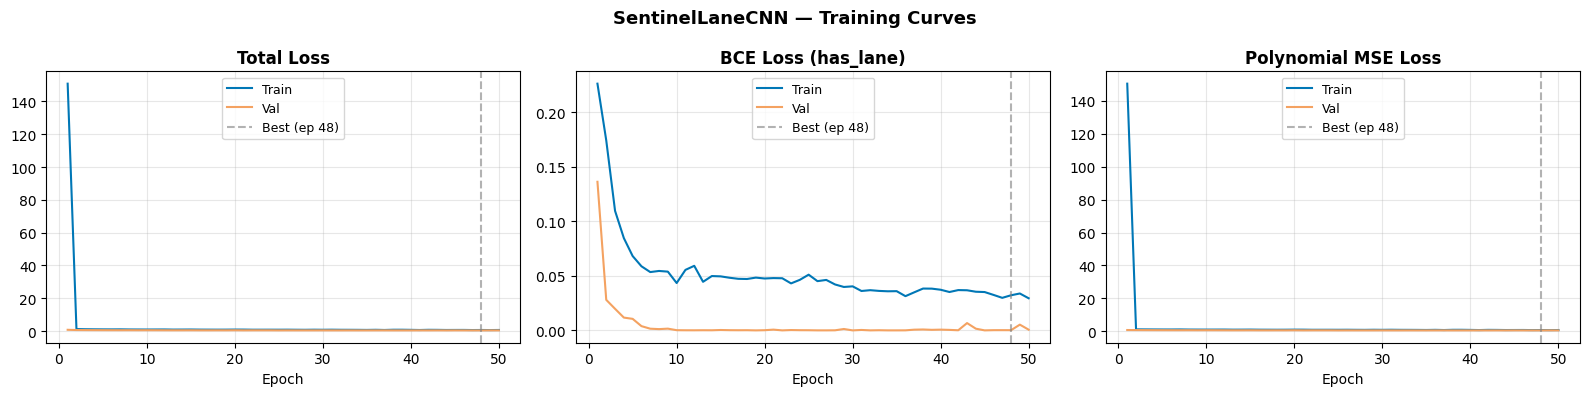

Saved: processed/cnn_loss_curves.png

Final train loss: 0.7110
Final val loss:   0.4724
Val − Train gap:   -0.2386  (acceptable)


In [7]:
epochs_ran = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("SentinelLaneCNN — Training Curves", fontsize=13, fontweight="bold")

plot_cfg = [
    ("train_loss", "val_loss", "Total Loss"),
    ("train_bce",  "val_bce",  "BCE Loss (has_lane)"),
    ("train_mse",  "val_mse",  "Polynomial MSE Loss"),
]

for ax, (tr_key, vl_key, title) in zip(axes, plot_cfg):
    ax.plot(epochs_ran, history[tr_key], label="Train", color="#0077B6", linewidth=1.5)
    ax.plot(epochs_ran, history[vl_key], label="Val",   color="#F4A261", linewidth=1.5)
    ax.axvline(best_epoch, color="gray", linestyle="--", alpha=0.6,
               label=f"Best (ep {best_epoch})")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
curves_path = PROCESSED_DIR / "cnn_loss_curves.png"
plt.savefig(str(curves_path), dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {curves_path}")

# Overfitting check
gap = history["val_loss"][-1] - history["train_loss"][-1]
print(f"\nFinal train loss: {history['train_loss'][-1]:.4f}")
print(f"Final val loss:   {history['val_loss'][-1]:.4f}")
print(f"Val − Train gap:   {gap:.4f}  ({'overfitting' if gap > 0.05 else 'acceptable'})")

---
## Cell 8 — Test set evaluation

Metrics:
- **has_lane accuracy** — classification threshold 0.5
- **Polynomial RMSE** — per-sample RMS pixel error between predicted and GT lane polynomials,
  sampled at 30 evenly spaced y-values in the ROI (lower 60% of image)
- **Steering error MAE** — |pred_midline_x − gt_midline_x| at the lookahead row

Results are saved to `processed/metrics_custom_cnn.json` for the comparison table in Notebook 05.

In [8]:
# Load best checkpoint
model.load_state_dict(torch.load(str(MODEL_PATH), map_location=DEVICE))
model.eval()

# Collect all predictions over the test set (loader order matches test_labels order)
all_pred_cls  = []   # scalar probability
all_pred_poly = []   # denormalised [la, lb, lc, ra, rb, rc]
all_true_cls  = []
all_true_poly_norm = []   # normalised (from dataset)

with torch.no_grad():
    for imgs, cls_t, poly_t in tqdm(test_loader, desc="Evaluating test set"):
        imgs = imgs.to(DEVICE)
        pred_cls_b, pred_poly_norm_b = model(imgs)

        # Denormalise predictions
        mn = torch.from_numpy(POLY_MEAN).to(DEVICE)
        st = torch.from_numpy(POLY_STD).to(DEVICE)
        pred_poly_raw_b = pred_poly_norm_b * st + mn

        all_pred_cls.extend(pred_cls_b.cpu().squeeze(1).tolist())
        all_pred_poly.extend(pred_poly_raw_b.cpu().tolist())
        all_true_cls.extend(cls_t.squeeze(1).tolist())
        all_true_poly_norm.extend(poly_t.tolist())

# Denormalise GT polys
true_poly_raw = np.array(all_true_poly_norm, dtype=np.float32) * POLY_STD + POLY_MEAN

# ── Classification accuracy ───────────────────────────────────
pred_cls_bin = [1 if p >= 0.5 else 0 for p in all_pred_cls]
true_cls_bin = [int(round(v)) for v in all_true_cls]
accuracy = sum(p == t for p, t in zip(pred_cls_bin, true_cls_bin)) / len(true_cls_bin)

# ── Polynomial RMSE and Steering MAE ───────────────────────────
roi_y_start = int(IMG_H * 0.40)
ys_eval     = np.linspace(roi_y_start, IMG_H - 1, 30)
y_la        = float(IMG_H - LOOKAHEAD_PX)

poly_rmses = []
steer_maes = []

for i, (p_poly, t_poly, has_l) in enumerate(zip(all_pred_poly, true_poly_raw, all_true_cls)):
    if has_l < 0.5:
        continue

    p_left  = p_poly[:3];  p_right = p_poly[3:]
    t_left  = t_poly[:3];  t_right = t_poly[3:]

    sq_errs = [
        (np.polyval(p_left,  y) - np.polyval(t_left,  y)) ** 2
        for y in ys_eval
    ] + [
        (np.polyval(p_right, y) - np.polyval(t_right, y)) ** 2
        for y in ys_eval
    ]
    poly_rmses.append(np.sqrt(np.mean(sq_errs)))

    pred_mid_x = (np.polyval(p_left, y_la) + np.polyval(p_right, y_la)) / 2.0
    true_mid_x = (np.polyval(t_left, y_la) + np.polyval(t_right, y_la)) / 2.0
    steer_maes.append(abs(pred_mid_x - true_mid_x))

poly_rmses = np.array(poly_rmses)
steer_maes = np.array(steer_maes)

# ── Print results ──────────────────────────────────────────
print(f"{'='*58}")
print(f"  CUSTOM CNN (SentinelLaneCNN) — TEST SET RESULTS")
print(f"{'='*58}")
print(f"  {'Metric':<36s}  {'Value':>12s}")
print(f"  {'-'*50}")
print(f"  {'has_lane accuracy':<36s}  {accuracy:>12.4f}")
print(f"  {'Poly RMSE mean (px)':<36s}  {poly_rmses.mean():>12.2f}")
print(f"  {'Poly RMSE median (px)':<36s}  {np.median(poly_rmses):>12.2f}")
print(f"  {'Poly RMSE std (px)':<36s}  {poly_rmses.std():>12.2f}")
print(f"  {'Steering MAE mean (px)':<36s}  {steer_maes.mean():>12.2f}")
print(f"  {'Steering MAE median (px)':<36s}  {np.median(steer_maes):>12.2f}")
print(f"  {'-'*50}")
print(f"  Evaluated on {len(poly_rmses)} samples (has_lane=True)")

# Save metrics for comparison table in Notebook 05
metrics = {
    "model":              "custom_cnn",
    "accuracy":           float(accuracy),
    "poly_rmse_mean":     float(poly_rmses.mean()),
    "poly_rmse_median":   float(np.median(poly_rmses)),
    "poly_rmse_std":      float(poly_rmses.std()),
    "steering_mae_mean":  float(steer_maes.mean()),
    "steering_mae_median":float(np.median(steer_maes)),
    "best_epoch":         best_epoch,
    "best_val_loss":      float(best_val_loss),
}
metrics_path = PROCESSED_DIR / "metrics_custom_cnn.json"
with open(str(metrics_path), "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)
print(f"\nMetrics saved to: {metrics_path}")

Evaluating test set: 100%|██████████| 18/18 [00:02<00:00,  7.67it/s]


  CUSTOM CNN (SentinelLaneCNN) — TEST SET RESULTS
  Metric                                       Value
  --------------------------------------------------
  has_lane accuracy                           1.0000
  Poly RMSE mean (px)                          61.22
  Poly RMSE median (px)                        32.40
  Poly RMSE std (px)                           58.91
  Steering MAE mean (px)                       45.15
  Steering MAE median (px)                     17.11
  --------------------------------------------------
  Evaluated on 545 samples (has_lane=True)

Metrics saved to: processed/metrics_custom_cnn.json


---
## Cell 9 — Test predictions visualisation

8 test samples showing GT lanes (thick) and predicted lanes (thin).
Steering error printed as `GT | Pred` at the lookahead row.

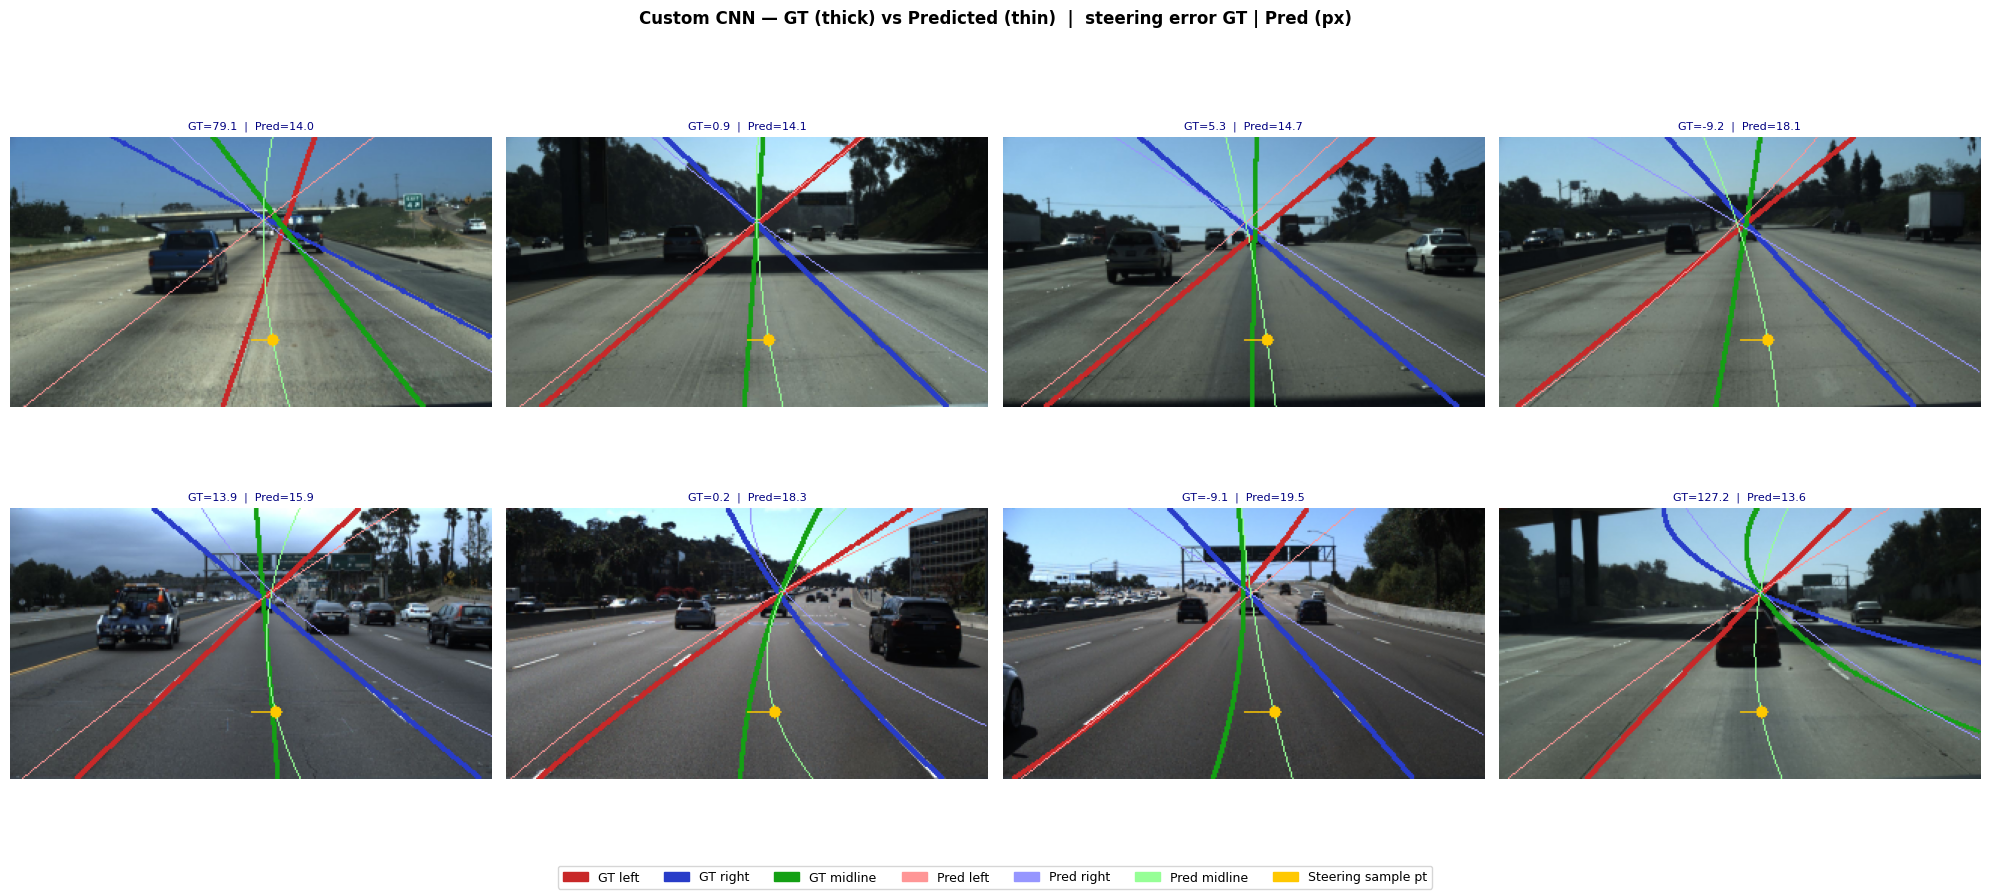

Saved: processed/cnn_test_predictions.png

Notebook 03 complete. Next: 04_transfer_learning.ipynb


In [9]:
def draw_poly_line(overlay, coeffs, color, thickness=2):
    """Draw a polynomial curve on a copy of overlay (in-place)."""
    pts = []
    for y in range(IMG_H):
        x = int(round(np.polyval(coeffs, y)))
        if 0 <= x < IMG_W:
            pts.append((x, y))
    for j in range(len(pts) - 1):
        cv2.line(overlay, pts[j], pts[j + 1], color, thickness)


rng = random.Random(SEED + 3)
vis_indices = rng.sample(range(len(test_labels)), min(8, len(test_labels)))

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(
    "Custom CNN — GT (thick) vs Predicted (thin)  |  steering error GT | Pred (px)",
    fontsize=12, fontweight="bold"
)

for ax, idx in zip(axes.flat, vis_indices):
    lbl = test_labels[idx]
    img = cv2.imread(lbl["image"])
    if img is None:
        ax.axis("off")
        continue

    overlay = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()

    p_poly = all_pred_poly[idx]
    p_left  = p_poly[:3];  p_right = p_poly[3:]
    p_mid   = [(l + r) / 2 for l, r in zip(p_left, p_right)]

    # GT (thick, saturated)
    if lbl["has_lane"]:
        draw_poly_line(overlay, lbl["left_poly"],  (200, 40,  40),  2)
        draw_poly_line(overlay, lbl["right_poly"], (40,  60,  200), 2)
        draw_poly_line(overlay, lbl["mid_poly"],   (20,  160, 20),  2)

    # Predictions (thin, lighter)
    draw_poly_line(overlay, p_left,  (255, 150, 150), 1)
    draw_poly_line(overlay, p_right, (150, 150, 255), 1)
    draw_poly_line(overlay, p_mid,   (150, 255, 150), 1)

    # Steering error indicator at lookahead row
    y_la_int = IMG_H - LOOKAHEAD_PX
    x_pred_mid = int(round((np.polyval(p_left, y_la_int) + np.polyval(p_right, y_la_int)) / 2))
    x_ctr = IMG_W // 2
    cv2.circle(overlay, (x_pred_mid, y_la_int), 4, (255, 200, 0), -1)
    cv2.line(overlay, (x_ctr, y_la_int), (x_pred_mid, y_la_int), (255, 200, 0), 1)

    pred_steer = (np.polyval(p_left, y_la_int) + np.polyval(p_right, y_la_int)) / 2 - IMG_W / 2
    gt_steer   = lbl["steering_error"] if lbl["has_lane"] else 0.0

    ax.imshow(overlay)
    ax.set_title(f"GT={gt_steer:.1f}  |  Pred={pred_steer:.1f}", fontsize=8, color="navy")
    ax.axis("off")

patches = [
    mpatches.Patch(color=(200/255, 40/255,  40/255),  label="GT left"),
    mpatches.Patch(color=(40/255,  60/255,  200/255), label="GT right"),
    mpatches.Patch(color=(20/255,  160/255, 20/255),  label="GT midline"),
    mpatches.Patch(color=(255/255, 150/255, 150/255), label="Pred left"),
    mpatches.Patch(color=(150/255, 150/255, 255/255), label="Pred right"),
    mpatches.Patch(color=(150/255, 255/255, 150/255), label="Pred midline"),
    mpatches.Patch(color=(255/255, 200/255, 0/255),   label="Steering sample pt"),
]
fig.legend(handles=patches, loc="lower center", ncol=7, fontsize=9)
plt.tight_layout()
vis_path = PROCESSED_DIR / "cnn_test_predictions.png"
plt.savefig(str(vis_path), dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {vis_path}")
print("\nNotebook 03 complete. Next: 04_transfer_learning.ipynb")